# LoanSight — Exploratory Data Analysis

This notebook explores the raw dataset to justify every design decision in `src/preprocessing.py` and `src/features.py`.

**Rule**: `fulldataset.csv` is used here ONLY — never in `src/` or `app/`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
%matplotlib inline

## Section 1 — Dataset Overview

In [2]:
train_df = pd.read_csv('../data/train.csv')
full_df  = pd.read_csv('../data/fulldataset.csv')

# test.csv may not exist yet
try:
    test_df = pd.read_csv('../data/test.csv')
    print(f'test  shape : {test_df.shape}')
except FileNotFoundError:
    test_df = None
    print('test.csv not found — skipping')

print(f'train shape : {train_df.shape}')
print(f'full  shape : {full_df.shape}')

test  shape : (58733, 33)
train shape : (293664, 34)
full  shape : (467201, 78)


In [3]:
print('=== Train columns ===')
print(train_df.dtypes)

print('\n=== Full dataset columns ===')
print(full_df.dtypes)

=== Train columns ===
ID                                  int64
agency                             object
loan_type                          object
property_type                      object
loan_purpose                       object
owner_occupancy                    object
loan_amount                       float64
preapproval                        object
msamd                              object
county                             object
county_code                       float64
census_tract_number               float64
applicant_ethnicity                object
applicant_race_name_1              object
applicant_race_name_2              object
applicant_race_name_3              object
co_applicant_ethnicity             object
co_applicant_race_name_1           object
co_applicant_race_name_2           object
co_applicant_race_name_3           object
applicant_sex                      object
co_applicant_sex                   object
applicant_income                  float64
lien_status 

In [4]:
train_df.head(3)

,ID,agency,loan_type,property_type,loan_purpose,owner_occupancy,loan_amount,preapproval,msamd,county,...,population,minority_population,hud_median_family_income,tract_to_msamd_income,number_of_owner_occupied_units,A,B,C,D,label
0,187616,Department of Housing and Urban Development,Conventional,One-to-four family dwelling (other than manufa...,Refinancing,Owner-occupied as a principal dwelling,160.0,Not applicable,"Lakeland, Winter Haven - FL",Polk County,...,5631.0,56.349998,52500.0,105.989998,1334.0,169.130727,NaN,2036.0,la,0
1,599925,Department of Housing and Urban Development,Conventional,One-to-four family dwelling (other than manufa...,Refinancing,Owner-occupied as a principal dwelling,235.0,NaN,"North Port, Sarasota, Bradenton - FL",Sarasota County,...,8958.0,13.610000,65500.0,89.489998,3015.0,170.521576,-3.525982,4461.0,la,0
2,139007,National Credit Union Administration,Conventional,One-to-four family dwelling (other than manufa...,Refinancing,Owner-occupied as a principal dwelling,311.0,Not applicable,"Tampa, St. Petersburg, Clearwater - FL",Hillsborough County,...,2919.0,8.050000,59800.0,191.929993,986.0,170.903815,-1.188552,1408.0,gh,1


## Section 2 — Class Distribution

Class distribution (train):
        Count  Percent
label                 
0      146832     50.0
1      146832     50.0


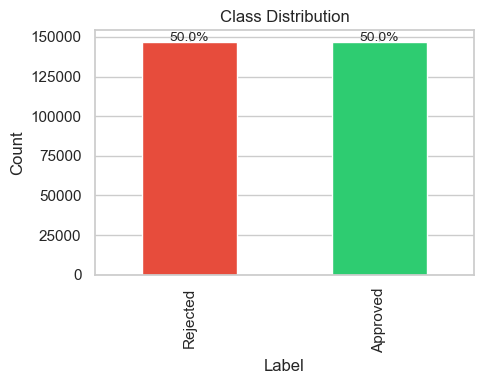


Imbalance ratio: 1.00:1
Decision: class_weight="balanced" recommended if ratio > 3:1


In [5]:
label_counts = train_df['label'].value_counts()
label_pct    = train_df['label'].value_counts(normalize=True) * 100

print('Class distribution (train):')
print(pd.DataFrame({'Count': label_counts, 'Percent': label_pct.round(2)}))

fig, ax = plt.subplots(figsize=(5, 4))
label_counts.rename({0: 'Rejected', 1: 'Approved'}).plot(kind='bar', ax=ax, color=['#e74c3c', '#2ecc71'])
ax.set_title('Class Distribution')
ax.set_xlabel('Label')
ax.set_ylabel('Count')
for bar, pct in zip(ax.patches, label_pct):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 500,
            f'{pct:.1f}%', ha='center', fontsize=10)
plt.tight_layout()
plt.show()

ratio = label_counts.max() / label_counts.min()
print(f'\nImbalance ratio: {ratio:.2f}:1')
print('Decision: class_weight="balanced" recommended if ratio > 3:1')

## Section 3 — Missing Values Analysis

In [6]:
missing_pct = (train_df.isnull().sum() / len(train_df) * 100).sort_values(ascending=False)
missing_pct = missing_pct[missing_pct > 0]

print('Columns with missing values (% in train):')
print(missing_pct.round(2).to_string())

Columns with missing values (% in train):
co_applicant_race_name_3          99.99
applicant_race_name_3             99.95
co_applicant_race_name_2          99.81
applicant_race_name_2             99.33
applicant_income                   9.40
msamd                              7.51
number_of_owner_occupied_units     7.09
hud_median_family_income           6.82
loan_purpose                       6.50
B                                  6.40
co_applicant_ethnicity             6.37
preapproval                        6.30
owner_occupancy                    6.04
applicant_sex                      5.98
tract_to_msamd_income              5.96
loan_type                          5.92
co_applicant_sex                   5.81
applicant_race_name_1              5.79
co_applicant_race_name_1           5.77
agency                             5.61
applicant_ethnicity                5.54
C                                  5.50
A                                  5.49
D                                  5.4

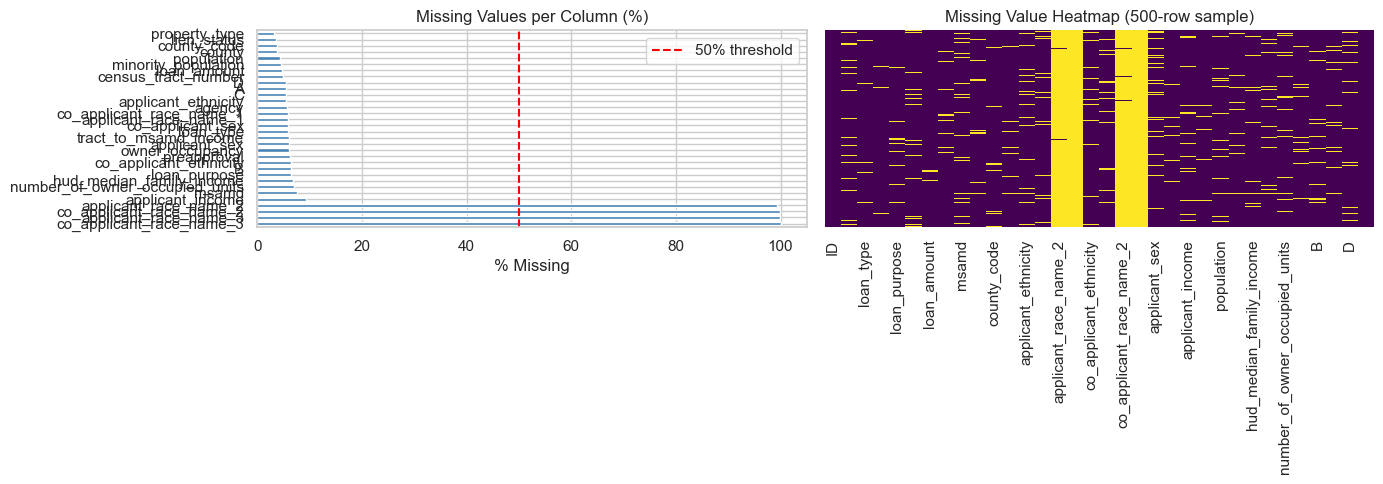


Decision: Drop columns with >50% missing: ['co_applicant_race_name_3', 'applicant_race_name_3', 'co_applicant_race_name_2', 'applicant_race_name_2']


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
missing_pct.plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].axvline(50, color='red', linestyle='--', label='50% threshold')
axes[0].set_title('Missing Values per Column (%)')
axes[0].set_xlabel('% Missing')
axes[0].legend()

# Heatmap (sample for readability)
sample = train_df.sample(min(500, len(train_df)), random_state=42)
sns.heatmap(sample.isnull(), cbar=False, yticklabels=False, ax=axes[1], cmap='viridis')
axes[1].set_title('Missing Value Heatmap (500-row sample)')

plt.tight_layout()
plt.show()

drop_candidates = missing_pct[missing_pct > 50].index.tolist()
print(f'\nDecision: Drop columns with >50% missing: {drop_candidates}')

## Section 4 — Numeric Feature Analysis

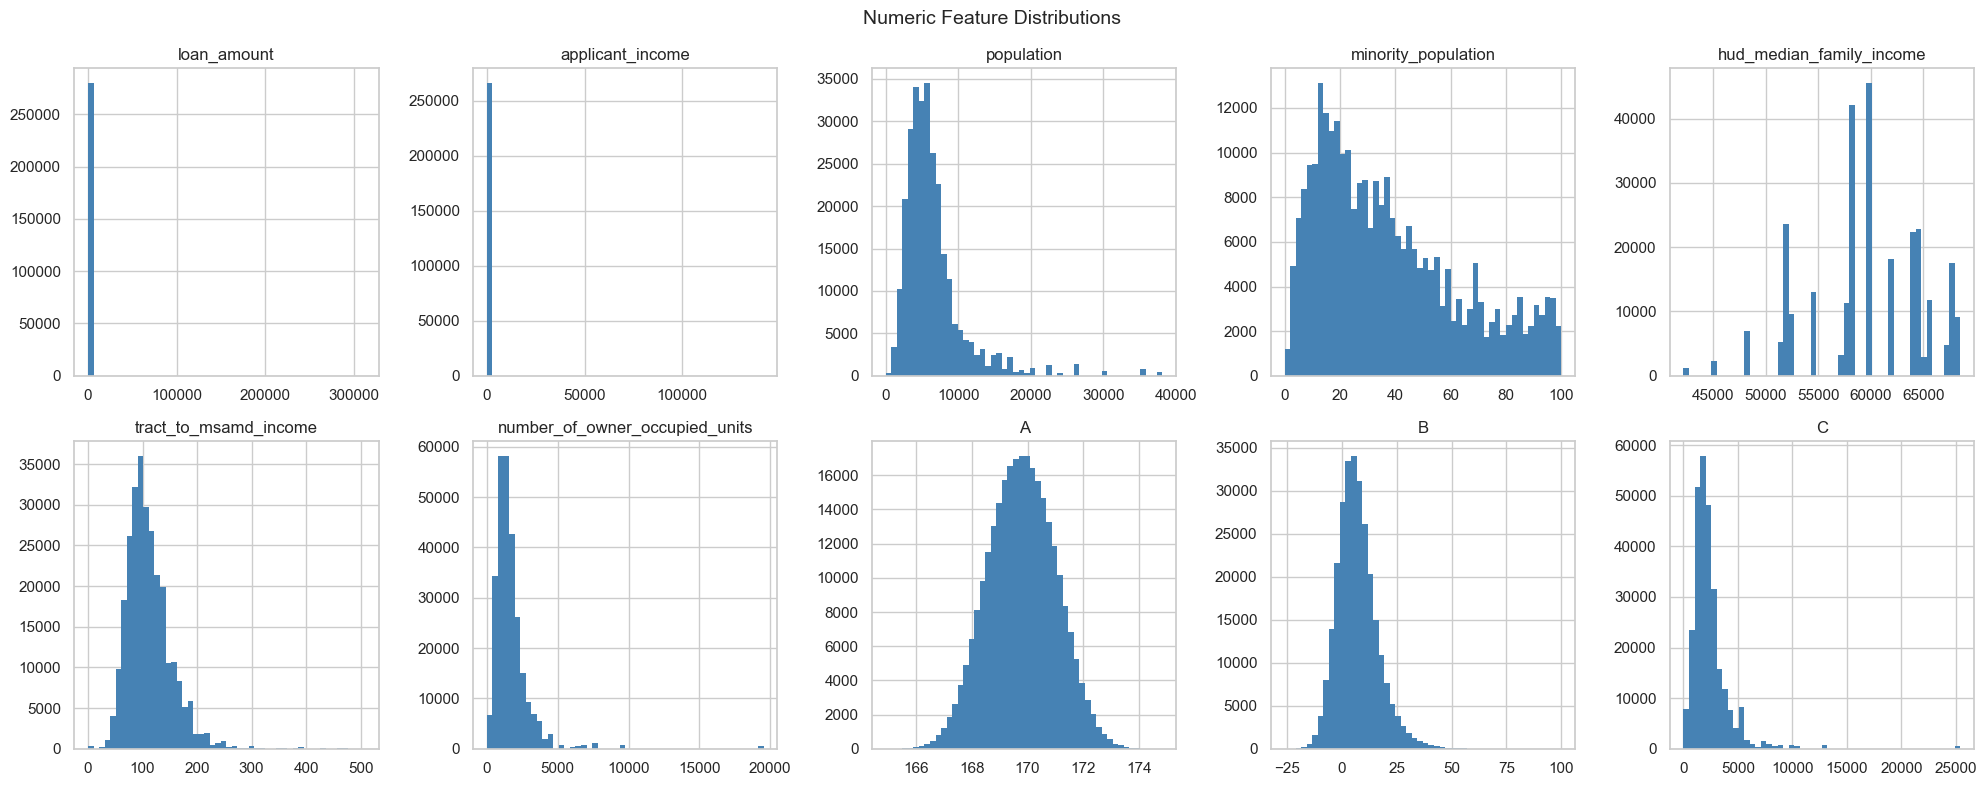

In [8]:
numeric_cols = ['loan_amount', 'applicant_income', 'population',
                'minority_population', 'hud_median_family_income',
                'tract_to_msamd_income', 'number_of_owner_occupied_units',
                'A', 'B', 'C']
numeric_cols = [c for c in numeric_cols if c in train_df.columns]

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    train_df[col].dropna().hist(bins=50, ax=axes[i], color='steelblue', edgecolor='none')
    axes[i].set_title(col)
    axes[i].set_xlabel('')

for j in range(len(numeric_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Numeric Feature Distributions', fontsize=14)
plt.tight_layout()
plt.show()

In [9]:
# Extended summary statistics
stats = train_df[numeric_cols].agg(['mean', 'std', 'skew', 'max']).T
stats['q99'] = train_df[numeric_cols].quantile(0.99)
stats['log_recommended'] = stats['skew'].abs() > 1
print(stats.round(2))
print('\nDecision: columns with |skew| > 1 should be log-transformed.')

                                    mean      std    skew        max  \
loan_amount                       210.96   974.28  167.99  312000.00   
applicant_income                  101.40   495.57  176.01  141700.00   
population                       6537.52  4403.11    2.93   38169.00   
minority_population                37.82    25.65    0.74     100.00   
hud_median_family_income        59729.02  5453.20   -0.43   68500.00   
tract_to_msamd_income             111.95    41.68    1.67     507.47   
number_of_owner_occupied_units   1682.50  1333.22    5.63   19529.00   
A                                 169.80     1.22    0.00     174.86   
B                                   6.98     9.25    0.87     100.10   
C                                2393.06  1824.96    4.89   25391.00   

                                     q99  log_recommended  
loan_amount                       939.00             True  
applicant_income                  582.00             True  
population                 

## Section 5 — Categorical Feature Analysis

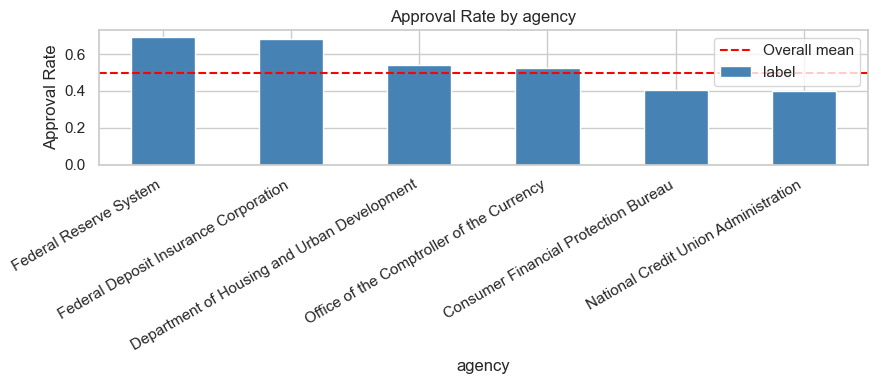

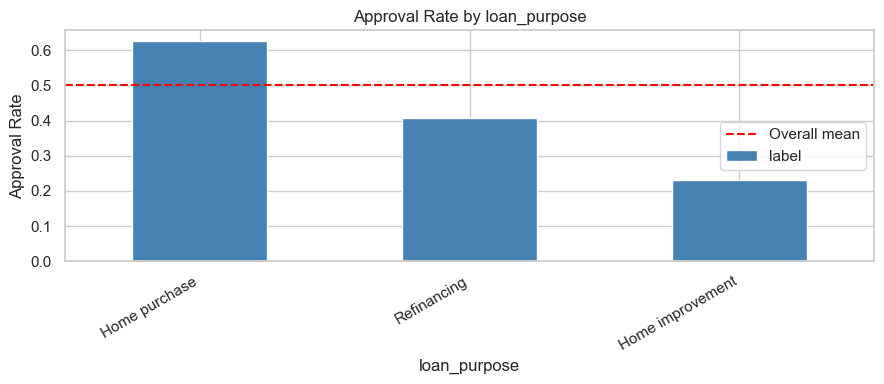

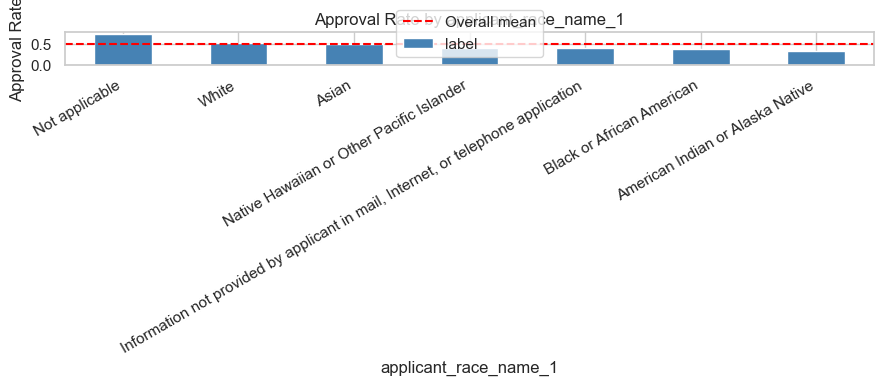

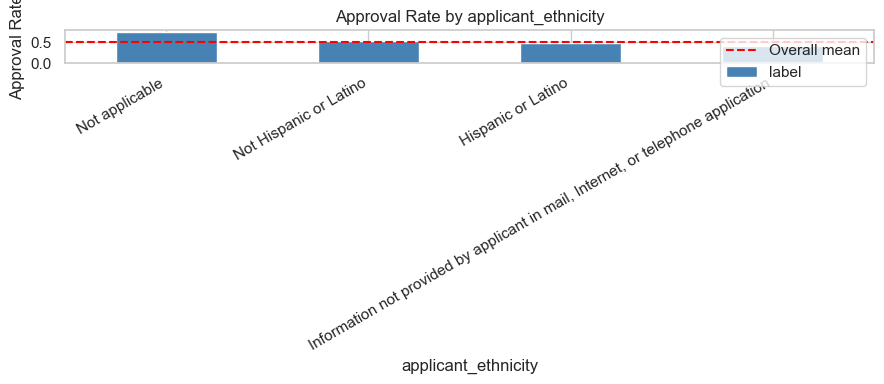

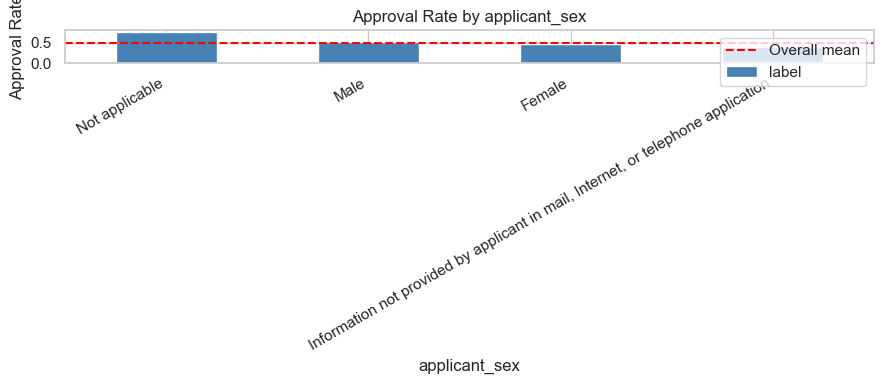

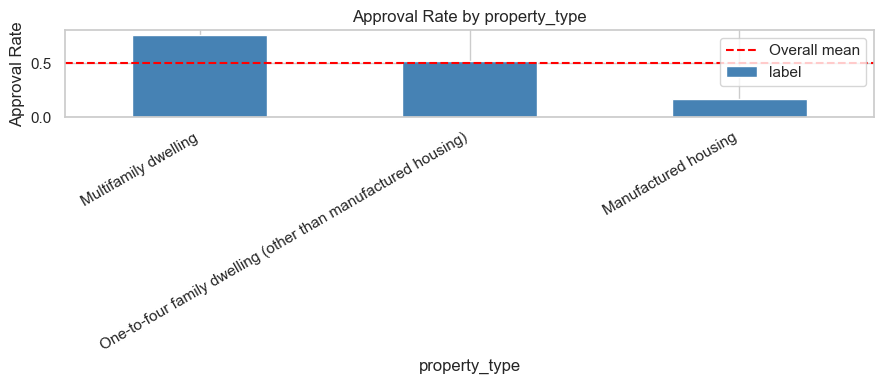

In [10]:
def plot_approval_rate(col, df=train_df, top_n=15, figsize=(9, 4)):
    """Bar chart of approval rate per category, sorted descending."""
    rates = df.groupby(col)['label'].mean().sort_values(ascending=False).head(top_n)
    fig, ax = plt.subplots(figsize=figsize)
    rates.plot(kind='bar', ax=ax, color='steelblue')
    ax.set_title(f'Approval Rate by {col}')
    ax.set_ylabel('Approval Rate')
    ax.set_xlabel(col)
    ax.axhline(df['label'].mean(), color='red', linestyle='--', label='Overall mean')
    ax.legend()
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout()
    plt.show()

for cat_col in ['agency', 'loan_purpose', 'applicant_race_name_1',
                'applicant_ethnicity', 'applicant_sex', 'property_type']:
    if cat_col in train_df.columns:
        plot_approval_rate(cat_col)

## Section 6 — Loan Amount Analysis

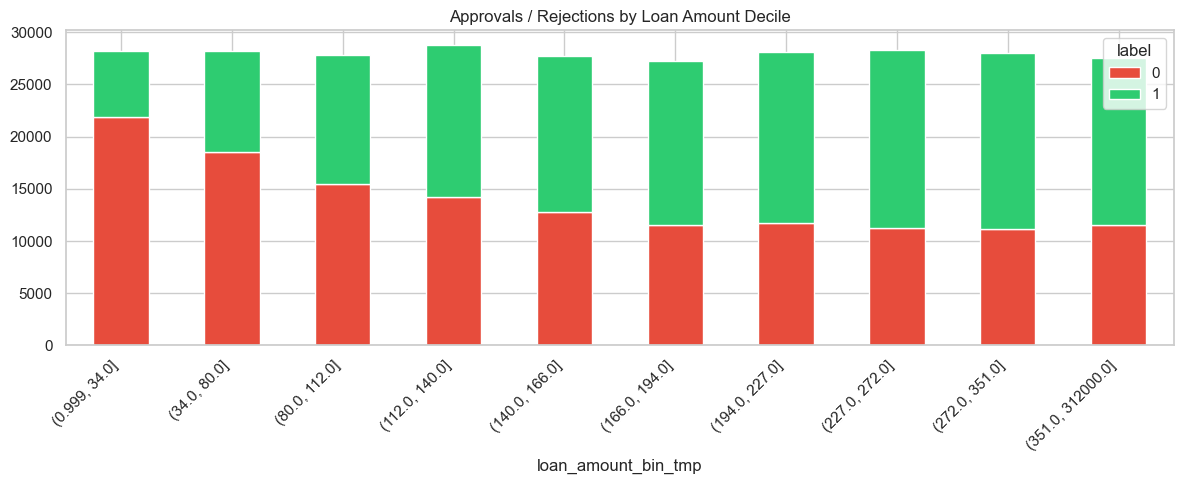

In [11]:
if 'loan_amount_bin' in train_df.columns:
    pivot = train_df.groupby(['loan_amount_bin', 'label']).size().unstack(fill_value=0)
    pivot.plot(kind='bar', stacked=True, figsize=(12, 5), color=['#e74c3c', '#2ecc71'])
    plt.title('Approvals / Rejections by Loan Amount Bin')
    plt.xlabel('Loan Amount Bin')
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    # Create bins on the fly
    train_df['loan_amount_bin_tmp'] = pd.qcut(train_df['loan_amount'], q=10, duplicates='drop')
    pivot = train_df.groupby(['loan_amount_bin_tmp', 'label']).size().unstack(fill_value=0)
    pivot.plot(kind='bar', stacked=True, figsize=(12, 5), color=['#e74c3c', '#2ecc71'])
    plt.title('Approvals / Rejections by Loan Amount Decile')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
    train_df.drop(columns=['loan_amount_bin_tmp'], inplace=True)

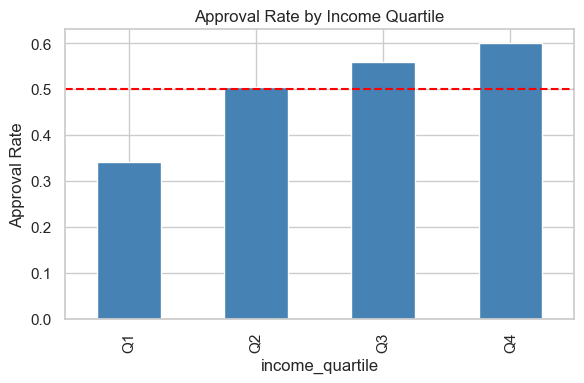

In [12]:
# Approval rate by income quartile
train_df['income_quartile'] = pd.qcut(train_df['applicant_income'], q=4,
                                       labels=['Q1', 'Q2', 'Q3', 'Q4'],
                                       duplicates='drop')
rates = train_df.groupby('income_quartile')['label'].mean()
fig, ax = plt.subplots(figsize=(6, 4))
rates.plot(kind='bar', ax=ax, color='steelblue')
ax.set_title('Approval Rate by Income Quartile')
ax.set_ylabel('Approval Rate')
ax.axhline(train_df['label'].mean(), color='red', linestyle='--')
plt.tight_layout()
plt.show()
train_df.drop(columns=['income_quartile'], inplace=True)

## Section 7 — Geographic Analysis

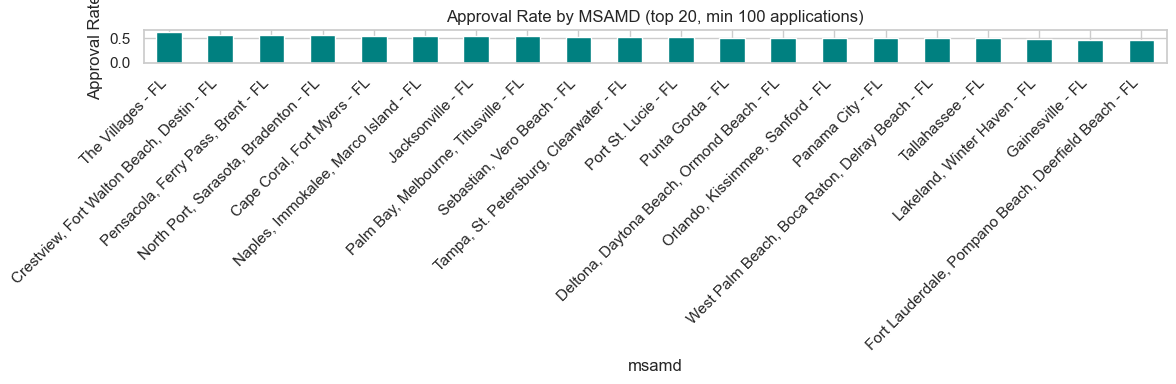

In [13]:
if 'msamd' in train_df.columns:
    msamd_rates = (train_df.groupby('msamd')['label']
                   .agg(['mean', 'count'])
                   .query('count >= 100')
                   .sort_values('mean', ascending=False)
                   .head(20))
    msamd_rates['mean'].plot(kind='bar', figsize=(12, 4), color='teal')
    plt.title('Approval Rate by MSAMD (top 20, min 100 applications)')
    plt.ylabel('Approval Rate')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

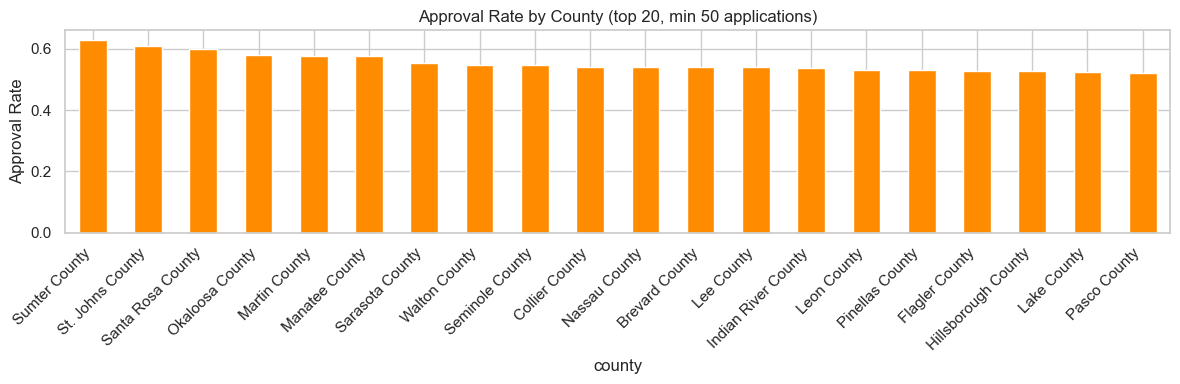

In [14]:
if 'county' in train_df.columns:
    county_rates = (train_df.groupby('county')['label']
                    .agg(['mean', 'count'])
                    .query('count >= 50')
                    .sort_values('mean', ascending=False)
                    .head(20))
    county_rates['mean'].plot(kind='bar', figsize=(12, 4), color='darkorange')
    plt.title('Approval Rate by County (top 20, min 50 applications)')
    plt.ylabel('Approval Rate')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

## Section 8 — Correlation Analysis

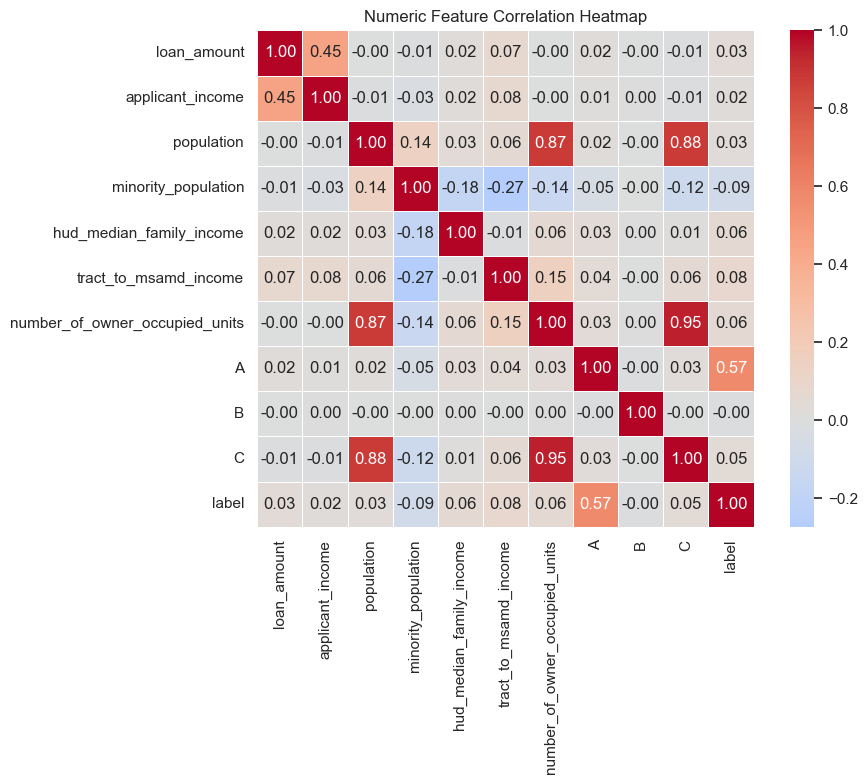

In [ ]:
corr_cols = [c for c in numeric_cols + ['label'] if c in train_df.columns]
corr = train_df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, ax=ax)
ax.set_title('Numeric Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

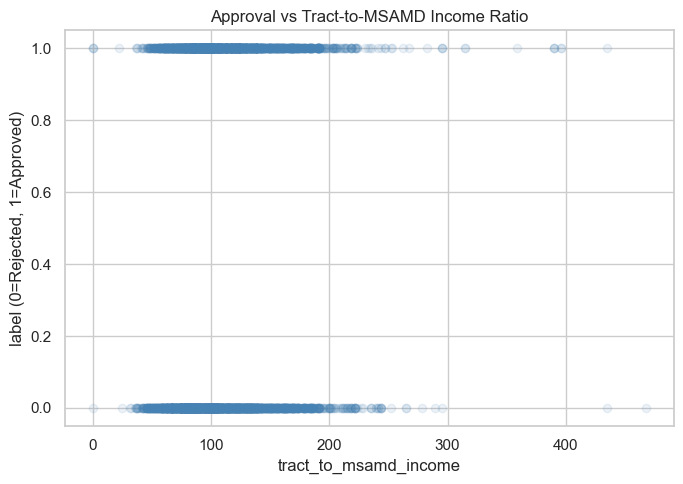

In [ ]:
if 'tract_to_msamd_income' in train_df.columns:
    sample = train_df.sample(min(5000, len(train_df)), random_state=42)
    fig, ax = plt.subplots(figsize=(7, 5))
    ax.scatter(sample['tract_to_msamd_income'], sample['label'],
               alpha=0.1, color='steelblue')
    ax.set_xlabel('tract_to_msamd_income')
    ax.set_ylabel('label (0=Rejected, 1=Approved)')
    ax.set_title('Approval vs Tract-to-MSAMD Income Ratio')
    plt.tight_layout()
    plt.show()

## Section 9 — Summary & Decisions

### Columns to Drop
- Columns with > 50% missing values (identified in Section 3)
- `county_code` (redundant with `county` name)
- `loan_amount_bin` (derived from `loan_amount` — would cause leakage)

### Columns Needing Log Transform
Based on skew analysis (Section 4), the following are right-skewed:
- `loan_amount`
- `applicant_income`
- `population`
- `minority_population`
- `hud_median_family_income`
- `number_of_owner_occupied_units`

### Encoding Strategy
| Column | Strategy | Reason |
|---|---|---|
| applicant_race_name_1 | Target mean encoding | High cardinality, approval rate varies by race |
| applicant_ethnicity | Normalize → numeric → target mean | Inconsistent labels |
| agency | Target mean encoding | Modest cardinality, approval rate varies by agency |
| loan_purpose | Target mean encoding | Low cardinality, strong signal |
| property_type | Target mean encoding | Low cardinality |
| applicant_sex | Target mean encoding | After standardization |
| census_tract_number | Target mean encoding | Very high cardinality — dummy encoding infeasible |
| county | Target mean encoding | High cardinality |
| msamd | Target mean encoding | Medium cardinality, strong geographic signal |
| D | Target mean encoding | Unknown column, treat as categorical |

### Class Weighting Decision
- Check imbalance ratio in Section 2
- If ratio > 3:1, use `class_weight='balanced'` in the MLP
- Otherwise, standard training is sufficient

### Model Selection
Run `experiments/model_comparison.py` to see 5-fold CV results across all candidate models.
The production model in `src/model.py` is the winner from that comparison.